# 6D-VHQ Analysis Notebook 5: Analysis of Experiment 2 (Strobe, lab study)

## Code Setup

In [1]:
## libraries
import pandas as pd
import numpy as np
from statsmodels.formula.api import ols
from scipy.stats import truncnorm
from scipy import stats
from statsmodels.stats.anova import AnovaRM
from statsmodels.regression.mixed_linear_model import MixedLM
from scipy.stats import f
from pathlib import Path
import os
from matplotlib.lines import Line2D
from matplotlib.ticker import NullLocator
import textwrap
import matplotlib.pyplot as plt
from scipy.stats import f
from statsmodels.stats.multitest import multipletests
from matplotlib.ticker import FuncFormatter



In [2]:
## toggle whether to save dataframes to csv

saving = False

## Helper functions

In [3]:
## Declaring important utility functions

## make a clamp function

def clamp(n, mini, maxi):
  return max(mini, min(n, maxi))

def noisify_list(the_list, noisyness):
  the_length = len(the_list)
  the_noise = list(np.random.normal(0, noisyness, the_length))
  return [x + y for x, y in zip(the_list, the_noise)]

def clamp_list(the_list, mini, maxi):
  return [clamp(i,mini,maxi) for i in the_list]


def noisify_clamp_list(the_list, noisyness, mini, maxi):
  return clamp_list(noisify_list(the_list, noisyness), mini, maxi)

def remap_number(number, old_min, old_max, new_min, new_max):
    """
    Remap a number from one range to another.

    Args:
    number (float): The number to remap.
    old_min (float): The lower bound of the original range.
    old_max (float): The upper bound of the original range.
    new_min (float): The lower bound of the new range.
    new_max (float): The upper bound of the new range.

    Returns:
    float: The number remapped to the new range.
    """
    # First, normalize the number to a 0-1 range (relative to the old range)
    normalized = (number - old_min) / (old_max - old_min)
    # Then scale to the new range
    return new_min + (normalized * (new_max - new_min))

def remap_list(the_list, oi, oa, ni, na):
  return [remap_number(i, oi, oa, ni, na) for i in the_list]

def add_truncated_normal_noise(predicted_values, mean_noise=0, sd_noise=0.71, lower_bound=1, upper_bound=5):
  """
  Adds truncated normal noise to a list of predicted values.

  Parameters:
      predicted_values (list of float): The list of predicted outcomes to which noise will be added.
      mean_noise (float): The mean of the truncated normal noise.
      sd_noise (float): The standard deviation of the truncated normal noise.
      lower_bound (float): The lower bound for the truncation of the normal distribution.
      upper_bound (float): The upper bound for the truncation of the normal distribution.

  Returns:
      list of float: The list of predicted outcomes with noise added.
  """
  # Ensure the bounds are adjusted to the mean noise for correct truncation
  adjusted_lower = (lower_bound - mean_noise) / sd_noise
  adjusted_upper = (upper_bound - mean_noise) / sd_noise

  noisy_data = []
  for value in predicted_values:
      # Generate truncated normal noise for each predicted value
      noise = truncnorm(a=adjusted_lower, b=adjusted_upper, loc=mean_noise, scale=sd_noise).rvs()
      noisy_value = value + noise
      # Ensure the noisy value does not exceed the limits
      noisy_value = max(lower_bound, min(upper_bound, noisy_value))
      noisy_data.append(noisy_value)

  return noisy_data

clamp function tests
should get 1 2.5 3
1 2.5 3
50.0
30.0


In [ ]:
### filepaths ###

project_path =  Path().resolve().parent 
tables_path = os.path.join(project_path, "tables_data")
qKeys_path = os.path.join(project_path, "question_keys")


## Data Input and Preprocessing

In [6]:
df_vhq_lab_dims = pd.read_csv(os.path.join(tables_path, "df_vhq_lab_dims.csv"))

display(df_vhq_lab_dims)

,pcode,condition,seat,trial_order,geometric,semantic,detail,vividness,entropy,focality
0,vs_22,0,1,53BA74C6021,2.000000,1.000000,1.666667,5.000000,1.000000,4.333333
1,vs_22,1,1,53BA74C6021,2.333333,1.000000,1.000000,4.000000,1.333333,5.000000
2,vs_22,2,1,53BA74C6021,2.000000,1.000000,1.000000,5.000000,1.333333,5.000000
3,vs_22,3,1,53BA74C6021,4.000000,1.333333,2.333333,3.666667,3.333333,5.000000
4,vs_22,4,1,53BA74C6021,5.000000,2.000000,4.666667,5.000000,2.333333,1.000000
...,...,...,...,...,...,...,...,...,...,...
600,vz036,6,3,253C671BA04,4.666667,1.000000,2.000000,2.000000,2.000000,3.333333
601,vz036,7,3,253C671BA04,1.000000,1.333333,1.000000,2.666667,1.666667,1.000000
602,vz036,A,3,253C671BA04,4.333333,2.333333,4.000000,4.000000,3.666667,1.666667
603,vz036,B,3,253C671BA04,5.000000,1.000000,2.666667,3.666667,1.000000,2.666667


In [7]:
### question key ###

# get and read excel file
vhq_key_path = os.path.join(qKeys_path, "VHQ_question_key.xlsx")
question_key = pd.read_excel(vhq_key_path)
question_key['q_col']   = question_key['question'].apply(lambda n: f"Q{n}")

### Dimension names ###
dimension_names = list(dict.fromkeys(question_key["name"]))
## remove infrequency dimension
dimension_names = dimension_names[:-1]

dimension_names


['geometric', 'semantic', 'detail', 'vividness', 'entropy', 'focality']

# Image Trial Analyssis and Exclusion

In [8]:
# Filter data for conditions B and C
condition_B_C = df_vhq_lab_dims[df_vhq_lab_dims['condition'].isin(['B', 'C'])]

# Re-creating the pivot table 
pivot_table = condition_B_C.pivot(index='pcode', columns='condition', values=dimension_names)

# Flatten column levels
pivot_table.columns = [f'{dim}_{cond}' for dim, cond in pivot_table.columns]

# Add 'AVERAGE' row by calculating the average of each column
pivot_table.loc['AVERAGE'] = pivot_table.mean()

# Calculate difference from average for each participant and average across all dimensions
pivot_table['error'] = pivot_table.apply(lambda row: np.mean(np.abs(row - pivot_table.loc['AVERAGE'])), axis=1)

pivot_table

,geometric_B,geometric_C,semantic_B,semantic_C,detail_B,detail_C,vividness_B,vividness_C,entropy_B,entropy_C,focality_B,focality_C,error
pcode,,,,,,,,,,,,,
vs_02,5.000000,1.000000,2.333333,5.000000,5.000000,5.000000,4.333333,1.000000,1.000000,2.333333,2.666667,1.000000,0.711616
vs_03,5.000000,1.333333,1.000000,5.000000,1.333333,4.000000,5.000000,1.666667,1.333333,3.666667,4.000000,1.333333,0.494949
vs_05,4.666667,1.000000,3.666667,5.000000,2.333333,4.333333,4.000000,2.000000,2.000000,4.666667,2.666667,1.333333,0.513636
vs_09,5.000000,1.000000,3.333333,5.000000,3.000000,4.666667,5.000000,2.666667,1.000000,3.000000,1.333333,1.000000,0.624242
vs_11,3.666667,1.000000,2.000000,5.000000,2.000000,4.000000,5.000000,3.333333,1.666667,2.666667,2.666667,1.000000,0.539394
vs_12,4.666667,1.000000,1.000000,5.000000,5.000000,4.333333,3.666667,3.333333,2.333333,4.333333,1.000000,1.000000,0.897980
vs_14,5.000000,1.000000,1.000000,4.000000,2.000000,3.666667,5.000000,2.666667,1.000000,2.666667,2.666667,1.666667,0.532828
vs_15,5.000000,1.000000,1.333333,4.666667,2.666667,4.333333,4.333333,1.000000,1.333333,1.333333,3.000000,1.000000,0.499495
vs_16,5.000000,1.333333,1.000000,5.000000,2.000000,4.000000,4.666667,1.000000,1.000000,3.000000,2.333333,2.000000,0.507576


pre-exclusion participants: 55
Average error: 0.6791735537190083
Standard deviation of error: 0.18193346938390578
Maximum allowable error: 1.04304049248682 (which is 2 standard deviations above the average)
Participants to exclude (above max error): ['vs_22', 'vx_06', 'vx_78', 'vz042']
Number of participants excluded: 4
Number of included participants: 51


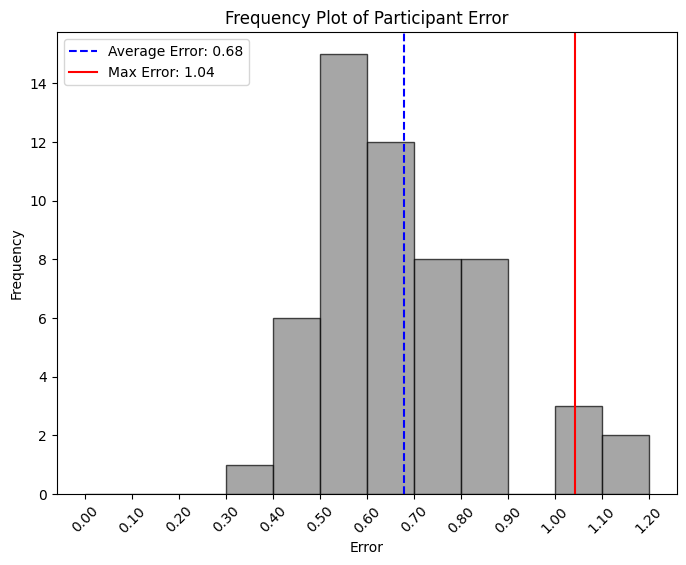

,pcode,condition,seat,trial_order,geometric,semantic,detail,vividness,entropy,focality
11,vs_29,0,2,53BA74C6021,2.333333,2.666667,1.000000,4.666667,2.333333,1.000000
12,vs_29,1,2,53BA74C6021,2.666667,1.333333,1.000000,5.000000,5.000000,1.000000
13,vs_29,2,2,53BA74C6021,3.333333,1.333333,1.666667,4.666667,5.000000,1.000000
14,vs_29,3,2,53BA74C6021,1.666667,1.666667,2.000000,3.666667,4.666667,2.000000
15,vs_29,4,2,53BA74C6021,2.666667,2.333333,1.333333,3.333333,4.333333,1.000000
...,...,...,...,...,...,...,...,...,...,...
600,vz036,6,3,253C671BA04,4.666667,1.000000,2.000000,2.000000,2.000000,3.333333
601,vz036,7,3,253C671BA04,1.000000,1.333333,1.000000,2.666667,1.666667,1.000000
602,vz036,A,3,253C671BA04,4.333333,2.333333,4.000000,4.000000,3.666667,1.666667
603,vz036,B,3,253C671BA04,5.000000,1.000000,2.666667,3.666667,1.000000,2.666667


In [9]:

pivot_table_no_average = pivot_table.drop(index='AVERAGE')

# Count the total number of participants before exclusion
total_participants_before = len(pivot_table_no_average)
print(f"pre-exclusion participants: {total_participants_before}")

# Calculate average and standard deviation of the error
average_error = pivot_table_no_average['error'].mean()
std_error = pivot_table_no_average['error'].std()

# Declare the maximum standard deviations above average error
maximum_stds_above_average_error = 2

# Calculate the maximum allowable error
maximum_error = average_error + maximum_stds_above_average_error * std_error

# Print out these numbers in a verbose way
print(f"Average error: {average_error}")
print(f"Standard deviation of error: {std_error}")
print(f"Maximum allowable error: {maximum_error} (which is {maximum_stds_above_average_error} standard deviations above the average)")

# Identify participants who need to be excluded (error greater than maximum_error)
participants_to_exclude = pivot_table_no_average [pivot_table_no_average['error'] > maximum_error].index.tolist()
num_excluded = len(participants_to_exclude)

# Print excluded participants and how many are excluded
print(f"Participants to exclude (above max error): {participants_to_exclude}")
print(f"Number of participants excluded: {num_excluded}")
print(f"Number of included participants: {total_participants_before - num_excluded}")


# Plot a frequency plot of the error with average error and max error marked
plt.figure(figsize=(8, 6))

# Define the bin width and calculate the number of bins based on the range (0 to 1.2)
bin_width = 0.1  # Adjust this value as needed
bins = np.arange(0, 1.2 + bin_width, bin_width)

# Create the histogram with the specified bin edges
counts, bin_edges, _ = plt.hist(pivot_table_no_average['error'], bins=bins, color='grey', edgecolor='black', alpha=0.7)

# Add vertical lines for average and max error
plt.axvline(average_error, color='blue', linestyle='--', label=f'Average Error: {average_error:.2f}')
plt.axvline(maximum_error, color='red', label=f'Max Error: {maximum_error:.2f}')

# Set the x-axis limits from 0 to 1.2
#plt.xlim(0, 1.2)

# Use the bin edges for tick locations and rotate them 45 degrees
plt.xticks(bin_edges, rotation=45)

# Format x-tick labels to two decimal places
plt.gca().xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'))

# Add title, labels, and legend
plt.title('Frequency Plot of Participant Error')
plt.xlabel('Error')
plt.ylabel('Frequency')
plt.legend()

# Show the plot
plt.show()

# Removing excluded participants from df_vhq_lab_dims to create df_vhq_lab_dims_excluded
df_vhq_lab_dims_excluded = df_vhq_lab_dims[~df_vhq_lab_dims['pcode'].isin(participants_to_exclude)]

df_vhq_lab_dims_excluded


In [10]:
## save new vhq df as a csv

## clean and check dimensional dataframe before saving

cols_to_drop = [
    "wrong_Q19", "wrong_Q20", "wrong_Q21",
    "n_wrong_row", "exclude_participant", "seat"
]

filename = "df_vhq_lab_dims_excluded.csv"

df_to_save = df_vhq_lab_dims_excluded

if saving:
    # 1. Save DataFrame
    csv_path = os.path.join(tables_path, filename)
    df_to_save.to_csv(csv_path, index=False)

    # 2. Read it back in
    df_check = pd.read_csv(csv_path)

    # 3. Display for checking
    display(df_check)

In [11]:
## create and save a similar df for the included items instead of dimensions 


## import the original table
df_vhq_lab_items = pd.read_csv(os.path.join(tables_path, "df_vhq_lab_items.csv"))

display(df_vhq_lab_items)

print("participants_to_exclude")
print(participants_to_exclude)

df_vhq_lab_items_excluded = df_vhq_lab_items[
    ~df_vhq_lab_items["pcode"].isin(participants_to_exclude)
].copy()

display(df_vhq_lab_items_excluded)


filename = "df_vhq_lab_items_excluded.csv"

df_to_save = df_vhq_lab_items_excluded

if saving:
    # 1. Save DataFrame
    csv_path = os.path.join(tables_path, filename)
    df_to_save.to_csv(csv_path, index=False)

    # 2. Read it back in
    df_check = pd.read_csv(csv_path)

    # 3. Display for checking
    display(df_check)

,pcode,condition,seat,trial_order,Q01,Q02,Q03,Q04,Q05,Q06,...,Q17,Q18,Q19,Q20,Q21,wrong_Q19,wrong_Q20,wrong_Q21,n_wrong_row,exclude_participant
0,vs_22,0,1,53BA74C6021,1,1,4,1,1,1,...,5,3,1,5,-1,False,False,False,0,False
1,vs_22,1,1,53BA74C6021,1,2,4,1,1,1,...,5,5,1,5,-1,False,False,False,0,False
2,vs_22,2,1,53BA74C6021,1,1,4,1,1,1,...,5,5,1,5,-1,False,False,False,0,False
3,vs_22,3,1,53BA74C6021,5,2,5,1,1,2,...,5,5,1,5,-1,False,False,False,0,False
4,vs_22,4,1,53BA74C6021,5,5,5,1,2,3,...,1,1,1,5,-1,False,False,False,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
600,vz036,6,3,253C671BA04,5,5,4,1,1,1,...,1,5,1,5,-1,False,False,False,0,False
601,vz036,7,3,253C671BA04,1,1,1,1,1,2,...,1,1,1,5,-1,False,False,False,0,False
602,vz036,A,3,253C671BA04,5,4,4,2,3,2,...,1,2,1,5,-1,False,False,False,0,False
603,vz036,B,3,253C671BA04,5,5,5,1,1,1,...,2,3,1,5,-1,False,False,False,0,False


participants_to_exclude
['vs_22', 'vx_06', 'vx_78', 'vz042']


,pcode,condition,seat,trial_order,Q01,Q02,Q03,Q04,Q05,Q06,...,Q17,Q18,Q19,Q20,Q21,wrong_Q19,wrong_Q20,wrong_Q21,n_wrong_row,exclude_participant
11,vs_29,0,2,53BA74C6021,1,1,5,1,4,3,...,1,1,1,5,-1,False,False,False,0,False
12,vs_29,1,2,53BA74C6021,2,1,5,1,1,2,...,1,1,1,5,-1,False,False,False,0,False
13,vs_29,2,2,53BA74C6021,4,1,5,1,1,2,...,1,1,1,5,-1,False,False,False,0,False
14,vs_29,3,2,53BA74C6021,3,1,1,1,1,3,...,2,1,1,5,-1,False,False,False,0,False
15,vs_29,4,2,53BA74C6021,4,2,2,1,2,4,...,1,1,1,5,-1,False,False,False,0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
600,vz036,6,3,253C671BA04,5,5,4,1,1,1,...,1,5,1,5,-1,False,False,False,0,False
601,vz036,7,3,253C671BA04,1,1,1,1,1,2,...,1,1,1,5,-1,False,False,False,0,False
602,vz036,A,3,253C671BA04,5,4,4,2,3,2,...,1,2,1,5,-1,False,False,False,0,False
603,vz036,B,3,253C671BA04,5,5,5,1,1,1,...,2,3,1,5,-1,False,False,False,0,False


## Working with light data

In [12]:
# Creating the new dataframe with conditions between '0' and '7' and converting the condition column to int
df_vhq_lab_dims_light = df_vhq_lab_dims_excluded[df_vhq_lab_dims_excluded['condition'].isin([str(i) for i in range(8)])].copy()

# Converting the condition column to int
df_vhq_lab_dims_light['condition'] = df_vhq_lab_dims_light['condition'].astype(int)

df_vhq_lab_dims_excluded

,pcode,condition,seat,trial_order,geometric,semantic,detail,vividness,entropy,focality
11,vs_29,0,2,53BA74C6021,2.333333,2.666667,1.000000,4.666667,2.333333,1.000000
12,vs_29,1,2,53BA74C6021,2.666667,1.333333,1.000000,5.000000,5.000000,1.000000
13,vs_29,2,2,53BA74C6021,3.333333,1.333333,1.666667,4.666667,5.000000,1.000000
14,vs_29,3,2,53BA74C6021,1.666667,1.666667,2.000000,3.666667,4.666667,2.000000
15,vs_29,4,2,53BA74C6021,2.666667,2.333333,1.333333,3.333333,4.333333,1.000000
...,...,...,...,...,...,...,...,...,...,...
600,vz036,6,3,253C671BA04,4.666667,1.000000,2.000000,2.000000,2.000000,3.333333
601,vz036,7,3,253C671BA04,1.000000,1.333333,1.000000,2.666667,1.666667,1.000000
602,vz036,A,3,253C671BA04,4.333333,2.333333,4.000000,4.000000,3.666667,1.666667
603,vz036,B,3,253C671BA04,5.000000,1.000000,2.666667,3.666667,1.000000,2.666667


In [13]:
## a full dimension names list for plots
dimension_names_full = dimension_names.copy()
dimension_names_full[0] = "geometric content"
dimension_names_full[1] = "semantic content"
dimension_names_full[2] = "detail level"
dimension_names_full

['geometric content',
 'semantic content',
 'detail level',
 'vividness',
 'entropy',
 'focality']

## Analysis 1 : Repeated Measures ANOVAs

In [14]:
custom_labels = ["2.5 Hz", "5 Hz", "8 Hz", "11 Hz", "16 Hz", "24 Hz", "40 Hz", "80 Hz"]

# Function to format p-value
def format_p_value_old(p, verbose = False):
  if verbose:
    if p < 0.001:
        return f"p={p:.3f} ***"
    elif p < 0.01:
        return f"p={p:.3f} **"
    elif p < 0.05:
        return f"p={p:.3f} *"
    else:
        return f"p={p:.3f} NS"
  else:
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

# Function to perform repeated measures ANOVA
def repeated_measures_anova(df, dimension):
    aovrm = AnovaRM(df, depvar=dimension, subject='pcode', within=['condition'])
    res = aovrm.fit()
    return res.anova_table['Pr > F'][0]

In [15]:

fz = 16


condition_mapping = {0: 2.5,  1 : 5, 2 : 8, 3 : 11, 4: 16, 5: 24, 6: 40, 7: 80}

# Variables for jitter
x_jitter = 0.4
y_jitter = 0.1



Supplementary table (dimension-wise rmANOVA with Holm correction across dimensions):
   dimension  df1  df2          F    eta_p2         p_raw    p_adj_holm  \
0  geometric    7  350  63.170746  0.558190  2.426202e-58  1.455721e-57   
1   semantic    7  350   0.487881  0.009663  8.433319e-01  8.433319e-01   
2     detail    7  350  31.625188  0.387444  6.723995e-34  3.361998e-33   
3  vividness    7  350   1.965103  0.037816  5.901060e-02  1.770318e-01   
4    entropy    7  350  29.994375  0.374956  2.120405e-32  8.481618e-32   
5   focality    7  350   1.686679  0.032633  1.110631e-01  2.221262e-01   

  p_raw_apa p_adj_apa  
0  p < .001  p < .001  
1  p = .843  p = .843  
2  p < .001  p < .001  
3  p = .059  p = .177  
4  p < .001  p < .001  
5  p = .111  p = .222  
geometric: F(7, 350) = 63.17, p < .001, ηₚ² = 0.558


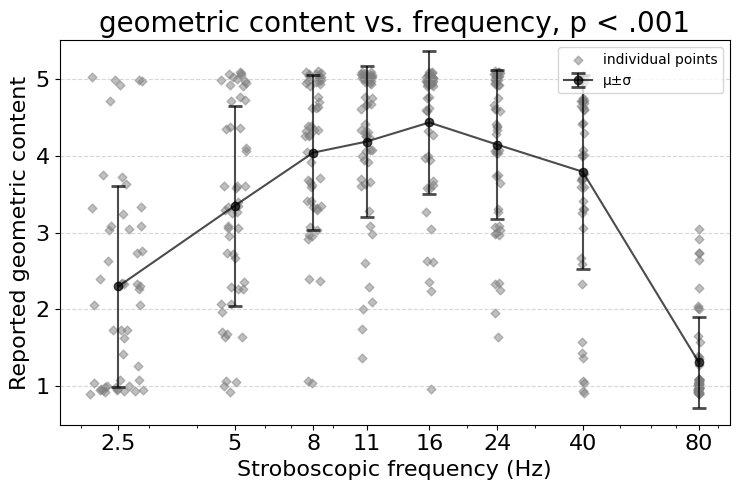

semantic: F(7, 350) = 0.49, p = .843, ηₚ² = 0.010


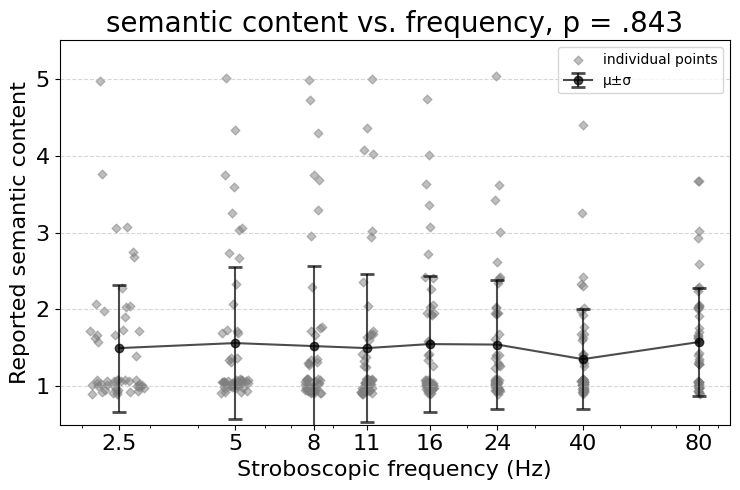

detail: F(7, 350) = 31.63, p < .001, ηₚ² = 0.387


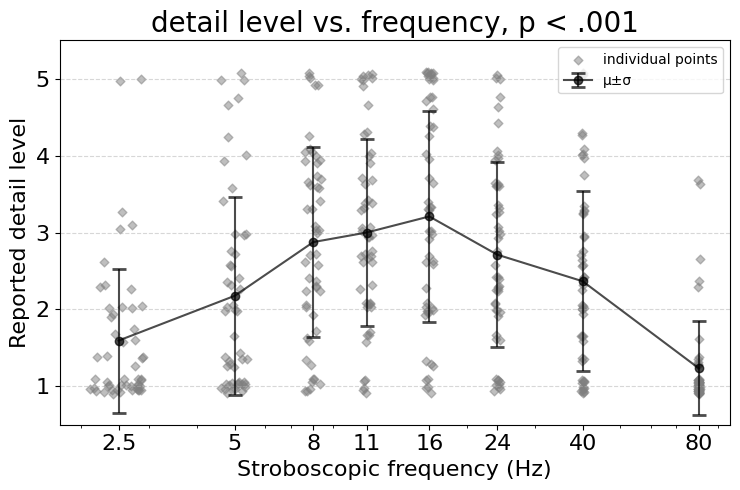

vividness: F(7, 350) = 1.97, p = .177, ηₚ² = 0.038


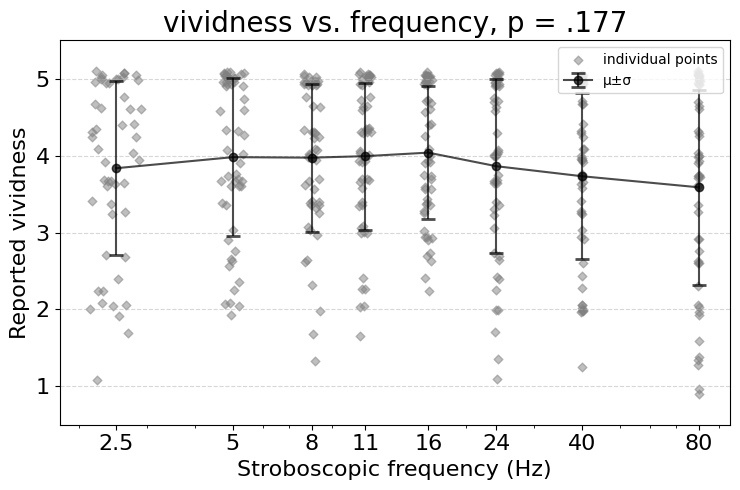

entropy: F(7, 350) = 29.99, p < .001, ηₚ² = 0.375


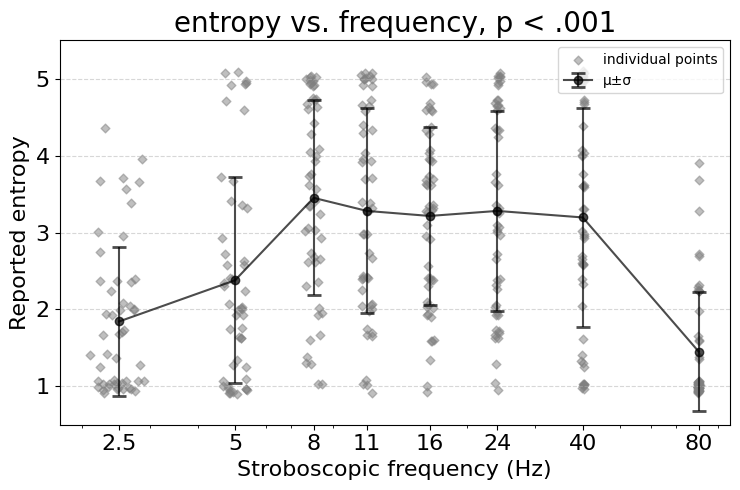

focality: F(7, 350) = 1.69, p = .222, ηₚ² = 0.033


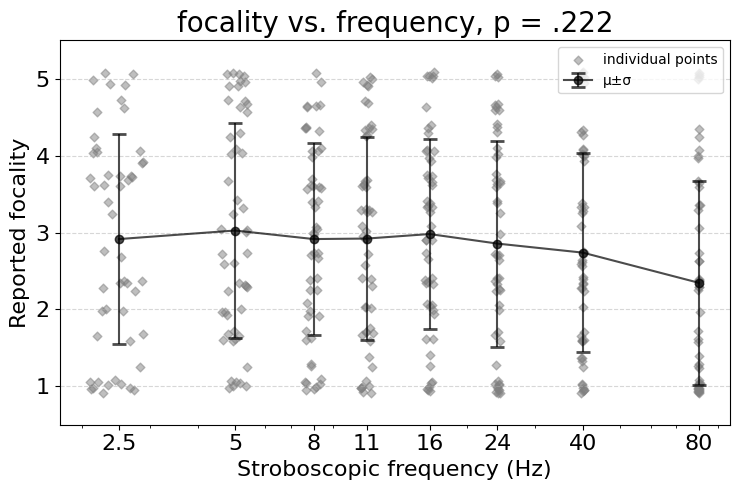

,dimension,df1,df2,F,eta_p2,p_raw,p_adj_holm,p_raw_apa,p_adj_apa
0,geometric,7,350,63.170746,0.558190,2.426202e-58,1.455721e-57,p < .001,p < .001
1,semantic,7,350,0.487881,0.009663,8.433319e-01,8.433319e-01,p = .843,p = .843
2,detail,7,350,31.625188,0.387444,6.723995e-34,3.361998e-33,p < .001,p < .001
3,vividness,7,350,1.965103,0.037816,5.901060e-02,1.770318e-01,p = .059,p = .177
4,entropy,7,350,29.994375,0.374956,2.120405e-32,8.481618e-32,p < .001,p < .001
5,focality,7,350,1.686679,0.032633,1.110631e-01,2.221262e-01,p = .111,p = .222


In [ ]:
def format_p(p):
    """
    Return a fully-formed APA p-value string:
      - "p < .001"    when p is below .001
      - "p = .XYZ"    otherwise, rounded to three decimals and no leading zero
    """
    if p < .001:
        return "p < .001"
    # round to 3 decimals, strip leading zero (".042", not "0.042")
    p_str = f"{p:.3f}".lstrip("0")
    return f"p = {p_str}"

dim_titles = []

def create_line_plot_with_std_and_scatter(df, dimensions, condition_mapping,
                                          x_jitter=0.2, y_jitter=0.1):
    """
    For each dimension, plots mean±std errorbars with jittered scatter,
    performs repeated‐measures ANOVA via AnovaRM, prints formatted ANOVA.

    pcode is the participant identifier for the repeated‐measures design.

    Applies Holm–Bonferroni correction across the set of dimension-wise ANOVAs
    (i.e., across the 6 dimensions for this analysis), and reports/plots p_adj.
    Also outputs a supplementary table with raw and adjusted p-values.
    """
    df_plot = df.copy()
    df_plot['condition_continuous'] = df_plot['condition'].map(condition_mapping)

    # ---------- Pass 1: run all ANOVAs, store results, compute Holm-adjusted p ----------
    results = []
    p_raw_list = []

    for i, dim in enumerate(dimensions):
        df_plot[dim] = pd.to_numeric(df_plot[dim], errors='coerce')

        aovrm = AnovaRM(df_plot, depvar=dim, subject='pcode', within=['condition'])
        res = aovrm.fit()
        table = res.anova_table.loc['condition']

        df1    = float(table['Num DF'])
        df2    = float(table['Den DF'])
        F_val  = float(table['F Value'])
        p_val  = float(table['Pr > F'])
        eta_p2 = (F_val * df1) / (F_val * df1 + df2)  # partial eta²

        results.append({
            "i": i,
            "dim": dim,
            "df1": df1,
            "df2": df2,
            "F": F_val,
            "p_raw": p_val,
            "eta_p2": eta_p2
        })
        p_raw_list.append(p_val)

    # Holm–Bonferroni across dimensions for this analysis
    p_adj = multipletests(p_raw_list, alpha=0.05, method='holm')[1]
    for r, p_a in zip(results, p_adj):
        r["p_adj"] = float(p_a)

    # Supplementary table output
    df_supp = pd.DataFrame([{
        "dimension": r["dim"],
        "df1": int(r["df1"]),
        "df2": int(r["df2"]),
        "F": r["F"],
        "eta_p2": r["eta_p2"],
        "p_raw": r["p_raw"],
        "p_adj_holm": r["p_adj"]
    } for r in results])

    # Optional: add APA-formatted columns (useful for quick copy/paste)
    df_supp["p_raw_apa"] = df_supp["p_raw"].apply(format_p)
    df_supp["p_adj_apa"] = df_supp["p_adj_holm"].apply(format_p)

    print("\nSupplementary table (dimension-wise rmANOVA with Holm correction across dimensions):")
    print(df_supp)

    # ---------- Pass 2: plot + in-text reporting using adjusted p ----------
    for r in results:
        i = r["i"]
        dim = r["dim"]
        F_val = r["F"]
        df1 = r["df1"]
        df2 = r["df2"]
        eta_p2 = r["eta_p2"]
        p_val_adj = r["p_adj"]

        plt.figure(figsize=(7.5, 5))
        df_plot[dim] = pd.to_numeric(df_plot[dim], errors='coerce')

        # Means & SD
        mean_vals = df_plot.groupby('condition_continuous')[dim].mean()
        std_vals  = df_plot.groupby('condition_continuous')[dim].std().fillna(0.0)
        x, y, err = mean_vals.index.values, mean_vals.values, std_vals.values

        plt.errorbar(x, y, yerr=err, fmt='-o', capsize=5, capthick=2,
                     alpha=0.7, color='black', label='μ±σ')
        plt.scatter(
            df_plot['condition_continuous'] +
                np.random.uniform(-x_jitter, x_jitter, size=len(df_plot)),
            df_plot[dim] +
                np.random.uniform(-y_jitter, y_jitter, size=len(df_plot)),
            alpha=0.5, color='grey', s=20, marker='D', label='individual points'
        )

        # APA-style in-text reporting now uses Holm-adjusted p
        formatted = (
            f"F({int(df1)}, {int(df2)}) = {F_val:.2f}, "
            f"{format_p(p_val_adj)}, "
            f"ηₚ² = {eta_p2:.3f}"
        )
        print(f"{dim}: {formatted}")
        p_text = f"{format_p(p_val_adj)}"

        title = f"{dimension_names_full[i]} vs. frequency, {p_text}"
        plt.title(
            title,
            fontsize=fz*1.25
        )

        dim_titles.append(title)

        plt.xscale('log')
        plt.xticks(list(condition_mapping.values()),
                   list(condition_mapping.values()), fontsize=fz)
        plt.xlabel('Stroboscopic frequency (Hz)', fontsize=fz)
        plt.ylabel(f'Reported {dimension_names_full[i]}', fontsize=fz)
        plt.ylim(0.5, 5.5)
        plt.yticks(np.arange(1, 6), np.arange(1, 6), fontsize=fz)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.legend(loc='upper right')
        plt.tight_layout()
        plt.show()

    return df_supp

# Usage (unchanged):
df_supp2 = create_line_plot_with_std_and_scatter(
    df_vhq_lab_dims_light,
    dimension_names,
    condition_mapping,
    x_jitter=x_jitter,
    y_jitter=y_jitter
)

df_supp2

# Analysis 2 : Polynomial Models

In [17]:


# Ensure the columns are numeric
df_vhq_lab_dims_light['condition'] = pd.to_numeric(df_vhq_lab_dims_light['condition'], errors='coerce')
#df_vhq_lab_dims_light['geometric'] = pd.to_numeric(df_vhq_lab_dims_light['geometric'], errors='coerce')

for dimension in dimension_names:
    df_vhq_lab_dims_light[dimension] = pd.to_numeric(df_vhq_lab_dims_light[dimension], errors='coerce')

# Drop rows with NaN values (if any)
df_vhq_lab_dims_light.dropna(inplace=True)

# Mapping condition to continuous values
condition_mapping = {0: 2.5, 1: 5, 2: 8, 3: 11, 4: 16, 5: 24, 6: 40, 7:80}
df_vhq_lab_dims_light['condition_continuous'] = df_vhq_lab_dims_light['condition'].map(condition_mapping)
df_vhq_lab_dims_light['condition_continuous'] = np.log10(df_vhq_lab_dims_light['condition_continuous'])

df_vhq_lab_dims_light

,pcode,condition,seat,trial_order,geometric,semantic,detail,vividness,entropy,focality,condition_continuous
11,vs_29,0,2,53BA74C6021,2.333333,2.666667,1.000000,4.666667,2.333333,1.000000,0.397940
12,vs_29,1,2,53BA74C6021,2.666667,1.333333,1.000000,5.000000,5.000000,1.000000,0.698970
13,vs_29,2,2,53BA74C6021,3.333333,1.333333,1.666667,4.666667,5.000000,1.000000,0.903090
14,vs_29,3,2,53BA74C6021,1.666667,1.666667,2.000000,3.666667,4.666667,2.000000,1.041393
15,vs_29,4,2,53BA74C6021,2.666667,2.333333,1.333333,3.333333,4.333333,1.000000,1.204120
...,...,...,...,...,...,...,...,...,...,...,...
597,vz036,3,3,253C671BA04,4.000000,3.000000,2.000000,3.000000,4.666667,3.000000,1.041393
598,vz036,4,3,253C671BA04,5.000000,2.000000,4.666667,3.666667,3.000000,4.666667,1.204120
599,vz036,5,3,253C671BA04,5.000000,2.000000,2.333333,3.666667,3.333333,2.666667,1.380211
600,vz036,6,3,253C671BA04,4.666667,1.000000,2.000000,2.000000,2.000000,3.333333,1.602060


In [18]:


def analyze_mixed_effects_polynomial_models_exploratory(
    df,
    y_value,
    condition_mapping,
    polynomial_orders,
    x_jitter=0.05,
    y_jitter=0.1,
    alpha_range=(8, 12),
    title = "",
    alpha = False,
    polynomial = False
):
    """
    Fits mixed‐effects polynomial models on log10(frequency), compares by F‐test,
    selects best order, and plots mean±σ, best‐fit curve, alpha range, and max point.
    """
    # copy & map
    df = df.copy()
    df['condition_continuous'] = df['condition'].map(condition_mapping)
    df['log_condition'] = np.log10(df['condition_continuous'])

    # fit mixed‐effects for each polynomial order
    models, sses = [], []
    for order in polynomial_orders:
        X_poly = np.vander(df['log_condition'], N=order+1, increasing=True)
        X_poly = pd.DataFrame(
            X_poly,
            columns=[f'log_x^{i}' for i in range(order+1)],
            index=df.index
        )
        m = MixedLM(df[y_value], X_poly, groups=df['pcode'])
        fit = m.fit()
        models.append(fit)
        sses.append(np.sum(fit.resid**2))

    # incremental F‐tests to pick best
    best_idx = 0
    print(f"Order {polynomial_orders[0]} SSE: {sses[0]:.3f}")
    for i in range(1, len(polynomial_orders)):
        o1, o2 = polynomial_orders[i-1], polynomial_orders[i]
        s1, s2 = sses[i-1], sses[i]
        df1 = len(df) - (o1 + 1)
        df2 = len(df) - (o2 + 1)
        F = ((s1 - s2)/(o2 - o1)) / (s2/df2)
        pval = f.sf(F, o2 - o1, df2)
        print(f"Compare {o1}→{o2}: F={F:.3f}, p={pval:.3f}")
        if pval < 0.05:
            best_idx = i
            print(f"  → significant improvement at order {o2}")
    best_order = polynomial_orders[best_idx]
    best_model = models[best_idx]
    if best_idx == 0:
        print("No significant improvement; using simplest model.")

    # plotting
    plt.figure(figsize=(7.5, 5))
    plt.rcParams.update({'font.size': 16})

    # means & stds on original scale
    means = df.groupby('condition_continuous')[y_value].mean()
    stds  = df.groupby('condition_continuous')[y_value].std().fillna(0.0)
    x_orig = means.index.values
    y_mean = means.values

    # mean±σ
    plt.errorbar(
        x_orig, y_mean,
        yerr=stds.values,
        fmt='-o', capsize=5, capthick=2,
        color='black' , label='mean ± sd'
    )

    if polynomial:
        # best‐fit polynomial on log scale
        log_min, log_max = df['log_condition'].min(), df['log_condition'].max()
        log_space = np.linspace(log_min, log_max, 200)
        Xp = np.vander(log_space, N=best_order+1, increasing=True)
        y_fit = best_model.predict(pd.DataFrame(Xp))
        freqs = 10**log_space
        plt.plot(
            freqs, y_fit,
            '-', linewidth=2,
            label=f'polynomial model'
        )

    # individual points with jitter
    xi = df['condition_continuous'].values
    yi = df[y_value].values
    xi_j = xi + np.random.uniform(-x_jitter, x_jitter, size=len(xi))
    yi_j = yi + np.random.uniform(-y_jitter, y_jitter, size=len(yi))
    plt.scatter(
        xi_j, yi_j,
        alpha=0.4, color='grey',
        s=15, marker='D',
        label='individual responses'
    )

    if alpha:
        # alpha band vertical lines
        a_min, a_max = alpha_range
        plt.axvline(a_min, linestyle=':', color='red', label='alpha band')
        plt.axvline(a_max, linestyle=':', color='red')

        # highlight max‐mean point
        idx_max = np.nanargmax(y_mean)
        x_best, y_best = x_orig[idx_max], y_mean[idx_max]
        plt.scatter(
            [x_best], [y_best],
            s=150, facecolors='none',
            edgecolors='red', linewidths=2,
            label='peak response frequency'
        )

    # axis & legend
    plt.xscale('log')
    plt.xticks(
        ticks=list(condition_mapping.values()),
        labels=list(condition_mapping.values())
    )
    plt.xlabel('Stroboscopic frequency (Hz, log scale)')
    plt.ylabel(y_value)
    plt.ylim(0.5, 5.5)
    plt.yticks(np.arange(1, 6), np.arange(1, 6))
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.title(f'Polynomial Model of {y_value}')
    plt.title(title, fontsize = fz *1.25) # manually setting title
    plt.legend(loc='best', frameon=True, fontsize=10)
    plt.tight_layout()
    plt.show()



e:\Research2\VHQ_final_validation_analysis\vhq_validation_analysis\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
e:\Research2\VHQ_final_validation_analysis\vhq_validation_analysis\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
e:\Research2\VHQ_final_validation_analysis\vhq_validation_analysis\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
e:\Research2\VHQ_final_validation_analysis\vhq_validation_analysis\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
e:\Research2\V

Order 0 SSE: 857.426
Compare 0→1: F=5.414, p=0.020
  → significant improvement at order 1
Compare 1→2: F=482.199, p=0.000
  → significant improvement at order 2
Compare 2→3: F=21.984, p=0.000
  → significant improvement at order 3
Compare 3→4: F=1.255, p=0.263
Compare 4→5: F=1.714, p=0.191


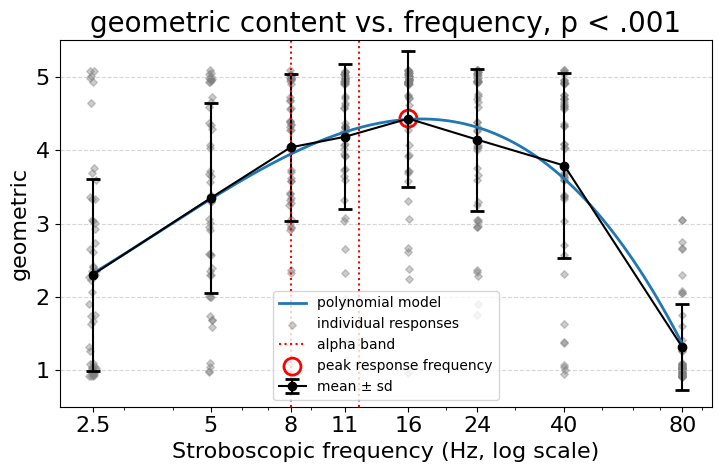

Order 0 SSE: 188.380
Compare 0→1: F=-0.012, p=1.000
Compare 1→2: F=-0.051, p=1.000
Compare 2→3: F=1.293, p=0.256
Compare 3→4: F=0.732, p=0.393
Compare 4→5: F=1.609, p=0.205
No significant improvement; using simplest model.


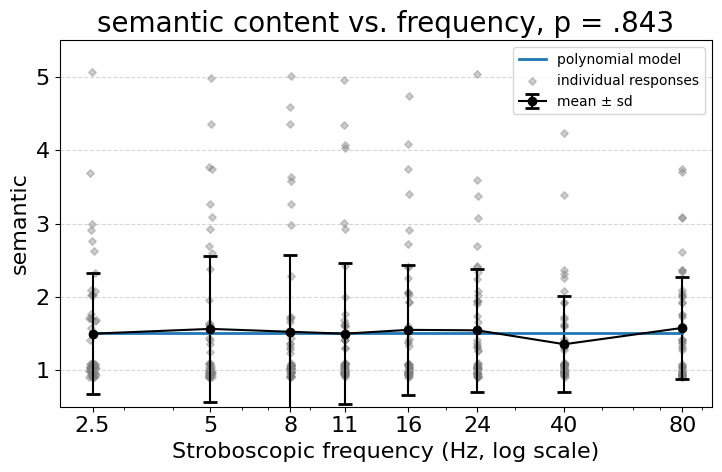

In [19]:
for i in range(0,2):
    analyze_mixed_effects_polynomial_models_exploratory(
        df_vhq_lab_dims_light, dimension_names[i], condition_mapping, [0, 1, 2, 3, 4, 5], 
        title=dim_titles[i],
        alpha = i==0,
        polynomial= i<2)

## A smaller plot which combines ANOVA and linear model analyses

C:\Users\Trevor\AppData\Local\Temp\ipykernel_8872\1512995079.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return res.anova_table['Pr > F'][0]
C:\Users\Trevor\AppData\Local\Temp\ipykernel_8872\1512995079.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return res.anova_table['Pr > F'][0]
C:\Users\Trevor\AppData\Local\Temp\ipykernel_8872\1512995079.py:28: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return res.anova_table

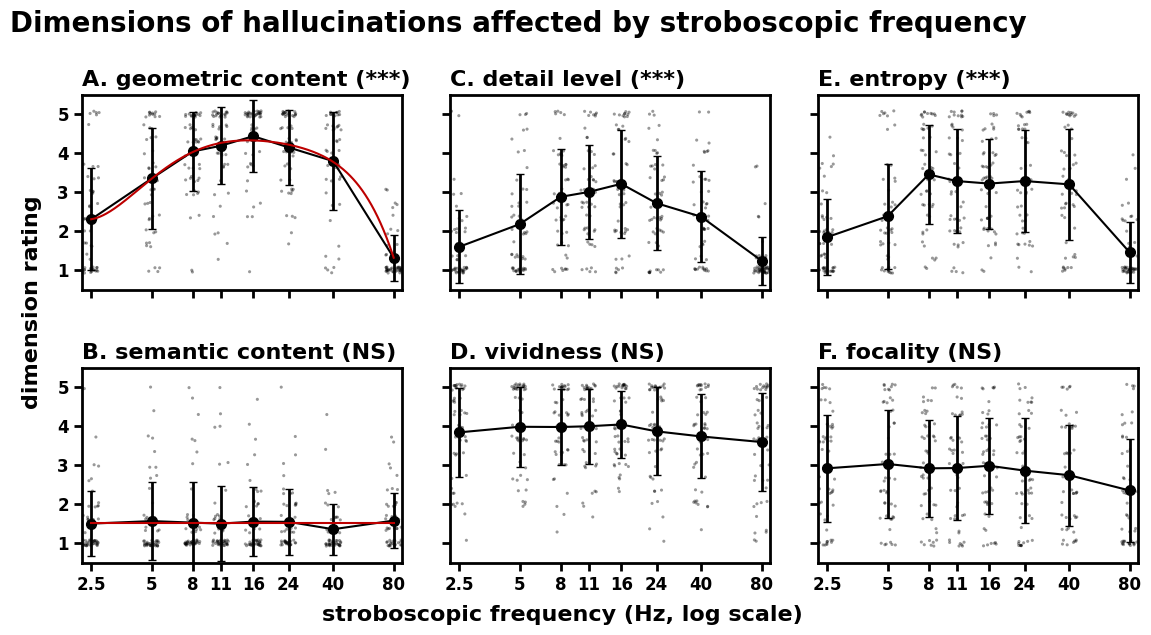

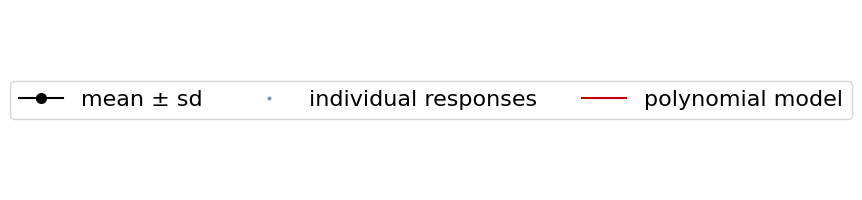

In [20]:


# =======================
# Adjustable visual params
# =======================
verbose = False  # set to False once everything looks correct

figsize = (12, 6.5)
n_rows, n_cols = 2, 3

base_fontsize       = 16
title_fontsize      = 16
axis_label_fontsize = 16
tick_label_fontsize = 12
suptitle_fontsize   = 20
suptitle_text       = "Dimensions of hallucinations affected by stroboscopic frequency"
suptitle_wrap_width = 400  # characters per line for automatic wrapping

scatter_size   = 5
scatter_alpha  = 0.4
mean_lw        = 1.5
error_capsize  = 3
error_eline_w  = 2.0
meansize       = 7
mean_fmt       = '-o'
poly_lw        = 1.5
poly_style     = 'solid'  # dotted
poly_degree    = 3  # polynomial degree for visual fit

# jitter
jitter_log_width = 0.04  # x jitter width in log10-space
y_jitter_width   = 0.08  # y jitter width in rating units (e.g. 0.08)

# colors
scatter_color = 'black'
mean_color    = 'black'
poly_color    = '#bd0000'

# axis / tick line widths
axis_lw = 2.0   # thickness of axes spines
tick_lw = 2.0   # thickness of tick marks
tick_len = 6    # length of tick marks

y_min, y_max = 0.5, 5.5
y_ticks      = np.arange(1, 6)

# which dimensions get the polynomial overlay (by index in dimension_names)
poly_dims_idx = {0, 1}   # 0: geometric, 1: semantic

# =======================
# Data preparation
# =======================
df_plot = df_vhq_lab_dims_excluded.copy()

# Coerce basic columns to numeric where relevant
df_plot['condition'] = pd.to_numeric(df_plot['condition'], errors='coerce')

# mapping: {0: 2.5, 1: 5, ...}
df_plot['condition_continuous'] = df_plot['condition'].map(condition_mapping)

# coerce all dimension columns to numeric (robust to string storage)
for dim_col in dimension_names:
    df_plot[dim_col] = pd.to_numeric(df_plot[dim_col], errors='coerce')

freq_values = list(condition_mapping.values())
freq_labels_raw = custom_labels  # e.g. ["2.5 Hz", "5 Hz", ...]
# strip " Hz" so ticks show only the number
freq_labels = [lbl.replace(" Hz", "") for lbl in freq_labels_raw]

if verbose:
    print("=== Global DF diagnostics ===")
    print("Columns:", df_plot.columns.tolist())
    print("Head:")
    print(df_plot.head())
    print("dtypes:")
    print(df_plot.dtypes)
    print("Unique conditions:", sorted(df_plot['condition'].dropna().unique()))
    print("Unique condition_continuous:", sorted(df_plot['condition_continuous'].dropna().unique()))
    print("dimension_names:", dimension_names)
    print("dimension_names2:", dimension_names_full)
    print()

# =======================
# Helper: jitter on log scale (x) and linear (y)
# =======================
rng = np.random.default_rng()

def jitter_log_x(x, log_width, rng=rng):
    """
    Apply uniform jitter of width `log_width` in log10-space,
    then convert back to linear Hz.
    """
    x = np.asarray(x, dtype=float)
    log_x = np.log10(x)
    jitter = rng.uniform(-log_width, log_width, size=log_x.shape)
    return 10 ** (log_x + jitter)

def jitter_y(y, width, rng=rng):
    """
    Apply uniform jitter of width `width` in linear y space.
    """
    y = np.asarray(y, dtype=float)
    jitter = rng.uniform(-width, width, size=y.shape)
    return y + jitter

# =======================
# Figure and axes
# =======================
plt.rcParams.update({'font.size': base_fontsize})
fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=figsize,
    sharex='col',
    sharey='row'
)

axes = np.array(axes).reshape(n_rows, n_cols)
max_panels = n_rows * n_cols

# =======================
# Main plotting loop
# =======================
for idx, (dim_name, dim_label) in enumerate(zip(dimension_names, dimension_names_full)):
    if idx >= max_panels:
        break

    # custom reordering for 3x2 grid to produce ACE / BDF layout
    reorder = [0, 3, 1, 4, 2, 5]
    target_idx = reorder[idx]   # where this plot should go

    row = target_idx // n_cols
    col = target_idx % n_cols

    ax = axes[row, col]

    # dimension-specific subset
    df_dim = df_plot[['pcode', 'condition', 'condition_continuous', dim_name]].copy()
    df_dim['condition_continuous'] = pd.to_numeric(df_dim['condition_continuous'], errors='coerce')
    df_dim[dim_name] = pd.to_numeric(df_dim[dim_name], errors='coerce')

    df_dim = df_dim.dropna(subset=['condition_continuous', dim_name])

    if verbose:
        print(f"--- Dimension {idx}: '{dim_name}' / label '{dim_label}' ---")
        print("df_dim shape:", df_dim.shape)
        print("  unique pcode:", df_dim['pcode'].nunique())
        print("  unique condition:", sorted(df_dim['condition'].dropna().unique()))
        print("  unique condition_continuous:", sorted(df_dim['condition_continuous'].dropna().unique()))
        print("  dim min/max:", df_dim[dim_name].min(), df_dim[dim_name].max())

    if df_dim.empty:
        if verbose:
            print("  WARNING: df_dim is empty, skipping plotting for this dimension.")
        continue

    # means and stds by condition_continuous
    means = df_dim.groupby('condition_continuous')[dim_name].mean()
    stds  = df_dim.groupby('condition_continuous')[dim_name].std().fillna(0.0)

    x_vals   = means.index.values
    y_means  = means.values
    y_stds   = stds.values

    if verbose:
        print("  groupby means index (x_vals):", x_vals)
        print("  means:", y_means)
        print("  stds:", y_stds)
        print()

    if len(x_vals) == 0:
        if verbose:
            print("  WARNING: no group means computed, skipping plotting.")
        continue

    # mean ± sd (zorder 2)
    ax.errorbar(
        x_vals, y_means,
        yerr=y_stds,
        fmt=mean_fmt,
        color=mean_color,
        linewidth=mean_lw,
        markersize=meansize,
        capsize=error_capsize,
        elinewidth=error_eline_w,
        zorder=2
    )

    # scatter points with x (log) and y jitter (zorder 1)
    x_raw = df_dim['condition_continuous'].values
    y_raw = df_dim[dim_name].values
    x_jit = jitter_log_x(x_raw, jitter_log_width)
    y_jit = jitter_y(y_raw, y_jitter_width)

    ax.scatter(
        x_jit, y_jit,
        s=scatter_size,
        alpha=scatter_alpha,
        marker='o',
        edgecolors='none',
        color=scatter_color,
        zorder=1
    )

    # dimension-specific polynomial degree:
    #   idx 0 → 5th-order polynomial
    #   idx 1 → 0th-order polynomial (flat line)
    #   others → no polynomial
    if idx in poly_dims_idx:
        if idx == 0:
            poly_degree_use = 5
        elif idx == 1:
            poly_degree_use = 0
        else:
            poly_degree_use = None

        if (poly_degree_use is not None) and (len(x_vals) > poly_degree_use):
            log_x = np.log10(x_vals)
            coeffs = np.polyfit(log_x, y_means, deg=poly_degree_use)
            poly   = np.poly1d(coeffs)

            log_space = np.linspace(log_x.min(), log_x.max(), 300)
            y_fit = poly(log_space)
            freqs_fit = 10 ** log_space

            ax.plot(
                freqs_fit, y_fit,
                linestyle=poly_style,
                linewidth=poly_lw,
                color=poly_color,
                zorder=4
            )

    # axes formatting
    ax.set_xscale('log')
    ax.set_xlim(min(freq_values) * 0.9, max(freq_values) * 1.1)
    ax.set_ylim(y_min, y_max)
    ax.set_yticks(y_ticks)
    ax.set_yticklabels([str(y) for y in y_ticks],
                       fontsize=tick_label_fontsize,
                       fontweight='bold')

    # x ticks only at stimulus frequencies, no minor ticks clutter
    ax.set_xticks(freq_values)
    if row == n_rows - 1:
        ax.set_xticklabels(freq_labels,
                           fontsize=tick_label_fontsize,
                           fontweight='bold')
    else:
        ax.set_xticklabels([])

    ax.xaxis.set_minor_locator(NullLocator())

    # ANOVA significance marker
    df_for_anova = (
        df_dim[['pcode', 'condition', dim_name]]
        .groupby(['pcode', 'condition'], as_index=False)[dim_name]
        .mean()
    )

    cond_counts = df_for_anova.groupby('pcode')['condition'].nunique()
    valid_pcodes = cond_counts[cond_counts == len(freq_values)].index
    df_for_anova = df_for_anova[df_for_anova['pcode'].isin(valid_pcodes)]

    if df_for_anova['pcode'].nunique() > 1:
        p_val = repeated_measures_anova(df_for_anova, dim_name)
    else:
        p_val = 1.0

    stars = format_p_value_old(p_val, verbose=False)
    if stars == "":
        stars = "NS"

    if verbose:
        print(f"  ANOVA p = {p_val:.4f}, stars = {stars}")
        print()

    # lettered, left-justified subplot titles: A., B., C., ...
    label_char = chr(ord('A') + idx)
    subplot_title = f"{label_char}. {dim_label} ({stars})"
    ax.set_title(
        subplot_title,
        fontsize=title_fontsize,
        fontweight='bold',
        loc='left'
    )

    # spine and tick styling
    for spine in ax.spines.values():
        spine.set_linewidth(axis_lw)

    ax.tick_params(
        axis='both',
        width=tick_lw,
        length=tick_len
    )

# reduce space between plots and leave room for wrapped suptitle
fig.subplots_adjust(
    left=0.10,
    right=0.98,
    bottom=0.10,
    top=0.82,   # lower top to give more room to the suptitle
    wspace=0.15,
    hspace=0.40
)

# shared axis labels
fig.text(
    0.5, 0.01,
    "stroboscopic frequency (Hz, log scale)",
    ha='center',
    fontsize=axis_label_fontsize,
    fontweight='bold'
)
fig.text(
    0.05, 0.5,
    "dimension rating",
    va='center',
    rotation='vertical',
    fontsize=axis_label_fontsize,
    fontweight='bold'
)

wrapped_suptitle = textwrap.fill(suptitle_text, width=suptitle_wrap_width)
fig.suptitle(
    wrapped_suptitle,
    fontsize=suptitle_fontsize,
    fontweight='bold',
    x=0.04,      # a bit in from the left edge
    y=0.95,
    ha='left'
)
plt.show()

# =======================
# Separate legend figure
# =======================
legend_fig, legend_ax = plt.subplots(figsize=(4, 2))

mean_handle = Line2D(
    [0], [0],
    color=mean_color,
    linewidth=mean_lw,
    marker='o',
    markersize=meansize,
    linestyle='-',
)
scatter_handle = Line2D(
    [0], [0],
    marker='o',
    linestyle='None',
    markersize=np.sqrt(scatter_size),
    markerfacecolor=scatter_color,
    alpha=scatter_alpha
)
poly_handle = Line2D(
    [0], [0],
    color=poly_color,
    linewidth=poly_lw,
    linestyle=poly_style
)

legend_ax.legend(
    [mean_handle, scatter_handle, poly_handle],
    ["mean ± sd", "individual responses", "polynomial model"],
    frameon=True,
    fontsize=base_fontsize,
    ncol=3,          # lay out entries left→right in one row
    loc='center'
)

legend_ax.axis('off')
legend_fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)
plt.show()


## Additional t tests

In [21]:


# Assumes df_vhq_lab_dims_excluded already exists with:
# columns: pcode, condition, geometric, semantic

# -----------------------------
# APA formatting helpers
# -----------------------------
def fmt_p(p, digits=3):
    # APA: omit leading zero; optionally use p < .001
    if p < 0.001:
        return "< .001"
    s = f"{p:.{digits}f}"  # e.g., "0.023"
    return s[1:] if s.startswith("0") else s  # -> ".023"

def fmt_msds(name, vals):
    m = float(np.mean(vals))
    sd = float(np.std(vals, ddof=1))
    return f"{name} (M = {m:.2f}, SD = {sd:.2f})"

# -----------------------------
# Condition names (no codes in output)
# -----------------------------
condition_names = {
    "A": "11 Hz sine wave",
    "3": "11 Hz square wave",
    "4": "16 Hz square wave",
    "7": "80 Hz control condition",
    "EXP": "Experimental conditions (0–6 averaged)",
}

# -----------------------------
# Paired test helper (by participant)
# -----------------------------
def paired_by_pcode(df, cond1, cond2, dv):
    sub = df[df["condition"].isin([cond1, cond2])][["pcode", "condition", dv]]
    wide = sub.pivot(index="pcode", columns="condition", values=dv).dropna()

    x = wide[cond1].astype(float)
    y = wide[cond2].astype(float)

    t, p = stats.ttest_rel(x, y)
    dfree = len(x) - 1

    diff = x - y
    dz = diff.mean() / diff.std(ddof=1)

    return x, y, dfree, t, p, dz

# =============================
# 1) 3 vs A paired, geometric
# =============================
x, y, dfree, t, p, dz = paired_by_pcode(df_vhq_lab_dims_excluded, "3", "A", "geometric")
print(fmt_msds(condition_names["3"], x.values))
print(fmt_msds(condition_names["A"], y.values))
print(f"paired: (t({dfree}) = {t:.2f}, p = {fmt_p(p)}, dz = {dz:.2f})")
print()

# =============================
# 2) 3 vs 4 paired, geometric
# =============================
x, y, dfree, t, p, dz = paired_by_pcode(df_vhq_lab_dims_excluded, "3", "4", "geometric")
print(fmt_msds(condition_names["3"], x.values))
print(fmt_msds(condition_names["4"], y.values))
print(f"paired: (t({dfree}) = {t:.2f}, p = {fmt_p(p)}, dz = {dz:.2f})")
print()

# =============================
# 3) (0–6 averaged) vs 7 paired, semantic
# =============================
df_sem = df_vhq_lab_dims_excluded[["pcode", "condition", "semantic"]].copy()

exp_avg = (
    df_sem[df_sem["condition"].isin(["0", "1", "2", "3", "4", "5", "6"])]
    .groupby("pcode")["semantic"]
    .mean()
)

ctrl = (
    df_sem[df_sem["condition"] == "7"]
    .set_index("pcode")["semantic"]
)

paired = pd.concat([exp_avg, ctrl], axis=1).dropna()
paired.columns = ["exp", "ctrl"]

x = paired["exp"].astype(float)
y = paired["ctrl"].astype(float)

t, p = stats.ttest_rel(x, y)
dfree = len(paired) - 1
diff = x - y
dz = diff.mean() / diff.std(ddof=1)

print(fmt_msds(condition_names["EXP"], x.values))
print(fmt_msds(condition_names["7"], y.values))
print(f"paired: (t({dfree}) = {t:.2f}, p = {fmt_p(p)}, dz = {dz:.2f})")


11 Hz square wave (M = 4.18, SD = 0.99)
11 Hz sine wave (M = 4.08, SD = 1.04)
paired: (t(50) = 0.55, p = .585, dz = 0.08)

11 Hz square wave (M = 4.18, SD = 0.99)
16 Hz square wave (M = 4.43, SD = 0.93)
paired: (t(50) = -1.44, p = .155, dz = -0.20)

Experimental conditions (0–6 averaged) (M = 1.50, SD = 0.62)
80 Hz control condition (M = 1.58, SD = 0.70)
paired: (t(50) = -0.57, p = .571, dz = -0.08)
